In [5]:
import torch
import torch.nn as nn
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
torch.manual_seed(42)

print("✅ Environment ready!")
print(f"PyTorch version: {torch.__version__}")

from transformers import GPT2Tokenizer, GPT2Model

✅ Environment ready!
PyTorch version: 2.9.1+cu128


In [18]:
"""
Create simple random embeddings
We're learning the MATH, not the meaning
"""

# Our imaginary sentence has 3 words
sentence = ["i", "love", "cats"]
seq_len = 3
d_model = 64  # Embedding dimension

# Create random embeddings
embeddings = torch.randn(seq_len, d_model) * 0.5

print(f"Sentence: {sentence}")
print(f"\nEmbeddings shape: {embeddings.shape}")
print(f"  - {seq_len} words")
print(f"  - {d_model} dimensions each")

print(f"\nFirst word embedding (first 10 dims):")
print(embeddings[0, :10])

print("\n💡 These are random - we're focusing on the PROCESS!")

Sentence: ['i', 'love', 'cats']

Embeddings shape: torch.Size([3, 64])
  - 3 words
  - 64 dimensions each

First word embedding (first 10 dims):
tensor([ 0.5149, -0.6615,  1.2452,  0.6607,  0.4710, -0.1894,  0.0233, -0.6563,
         0.1740,  0.7215])

💡 These are random - we're focusing on the PROCESS!


In [19]:
"""
Create random projection matrices for Query, Key, Value
In real training, these would be learned
"""

# Random weight matrices
weight_query = torch.randn(d_model, d_model) * 0.01
weight_key = torch.randn(d_model, d_model) * 0.01
weight_value = torch.randn(d_model, d_model) * 0.01

print("Projection matrices:")
print(f"weight_query shape: {weight_query.shape}")
print(f"weight_key shape: {weight_key.shape}")
print(f"weight_value shape: {weight_value.shape}")

# Project embeddings to Q, K, V
queries = embeddings @ weight_query
keys = embeddings @ weight_key
values = embeddings @ weight_value

print(f"\n✨ Created Q, K, V:")
print(f"queries shape: {queries.shape}")
print(f"keys shape: {keys.shape}")
print(f"values shape: {values.shape}")

print(f"\nFirst word query (first 10 dims):")
print(queries[0, :10])

Projection matrices:
weight_query shape: torch.Size([64, 64])
weight_key shape: torch.Size([64, 64])
weight_value shape: torch.Size([64, 64])

✨ Created Q, K, V:
queries shape: torch.Size([3, 64])
keys shape: torch.Size([3, 64])
values shape: torch.Size([3, 64])

First word query (first 10 dims):
tensor([-0.0399,  0.0148, -0.0522,  0.0141, -0.0263,  0.0559, -0.0162, -0.0154,
        -0.0428,  0.0123])


In [20]:
"""
Step 1 of Attention: Calculate how much each word should attend to every other word
Formula: attention_scores = queries @ keys^T
"""

# Calculate raw attention scores
attention_scores = queries @ keys.T

print("📊 Attention Scores (before scaling):")
print(attention_scores)
print(f"\nShape: {attention_scores.shape}")
print("  → [3, 3] means each of 3 words has a score with all 3 words")

print("\n🔍 What does this mean?")
print(f"attention_scores[0, 0] = {attention_scores[0, 0].item():.4f}")
print("  → How much word1 'relates to' word1 (itself)")

print(f"\nattention_scores[0, 1] = {attention_scores[0, 1].item():.4f}")
print("  → How much word1 'relates to' word2")

print(f"\nattention_scores[0, 2] = {attention_scores[0, 2].item():.4f}")
print("  → How much word1 'relates to' word3")

print("\n💡 Higher score = stronger relationship")
print("These scores will be used to decide attention weights!")

📊 Attention Scores (before scaling):
tensor([[ 0.0078, -0.0062, -0.0003],
        [ 0.0107, -0.0211,  0.0283],
        [ 0.0214, -0.0054, -0.0115]])

Shape: torch.Size([3, 3])
  → [3, 3] means each of 3 words has a score with all 3 words

🔍 What does this mean?
attention_scores[0, 0] = 0.0078
  → How much word1 'relates to' word1 (itself)

attention_scores[0, 1] = -0.0062
  → How much word1 'relates to' word2

attention_scores[0, 2] = -0.0003
  → How much word1 'relates to' word3

💡 Higher score = stronger relationship
These scores will be used to decide attention weights!


In [22]:
"""
Step 2: Scale the scores by sqrt(d_k)
Step 3: Apply softmax to convert to probabilities
"""

import math

# Get the dimension for scaling
d_k = queries.shape[-1]  # 64
print(f"Key dimension (d_k): {d_k}")
print(f"Scale factor (√d_k): {math.sqrt(d_k):.4f}")

# Scale the scores
attention_scores_scaled = attention_scores / math.sqrt(d_k)

print(f"\n📊 BEFORE scaling:")
print(attention_scores)
print(f"\n📊 AFTER scaling (divided by √{d_k} = {math.sqrt(d_k):.2f}):")
print(attention_scores_scaled)

print(f"\n💡 Why scale?")
print(f"Without scaling, scores can get very large → softmax saturates")
print(f"Scaling keeps values in a reasonable range")

# Apply softmax to get attention weights (probabilities)
attention_weights = torch.softmax(attention_scores_scaled, dim=-1)

print(f"\n✨ ATTENTION WEIGHTS (after softmax):")
print(attention_weights)

print(f"\n🔍 Key properties:")
print(f"Each row sums to 1.0:")
print(f"Row 0 sum: {attention_weights[0].sum():.6f}")
print(f"Row 1 sum: {attention_weights[1].sum():.6f}")
print(f"Row 2 sum: {attention_weights[2].sum():.6f}")

print(f"\nAll values are between 0 and 1:")
print(f"Min value: {attention_weights.min():.6f}")
print(f"Max value: {attention_weights.max():.6f}")

print(f"\n🎯 Interpretation (even though values are random):")
sentence = ["word1", "word2", "word3"]
for i, word in enumerate(sentence):
    print(f"\n'{word}' attention distribution:")
    for j, other_word in enumerate(sentence):
        weight = attention_weights[i, j].item()
        bar = "█" * int(weight * 50)
        print(f"  {other_word:8s}: {weight:.3f} {bar}")

Key dimension (d_k): 64
Scale factor (√d_k): 8.0000

📊 BEFORE scaling:
tensor([[ 0.0078, -0.0062, -0.0003],
        [ 0.0107, -0.0211,  0.0283],
        [ 0.0214, -0.0054, -0.0115]])

📊 AFTER scaling (divided by √64 = 8.00):
tensor([[ 9.7375e-04, -7.7599e-04, -3.6468e-05],
        [ 1.3315e-03, -2.6384e-03,  3.5343e-03],
        [ 2.6788e-03, -6.6968e-04, -1.4437e-03]])

💡 Why scale?
Without scaling, scores can get very large → softmax saturates
Scaling keeps values in a reasonable range

✨ ATTENTION WEIGHTS (after softmax):
tensor([[0.3336, 0.3331, 0.3333],
        [0.3335, 0.3322, 0.3343],
        [0.3342, 0.3330, 0.3328]])

🔍 Key properties:
Each row sums to 1.0:
Row 0 sum: 1.000000
Row 1 sum: 1.000000
Row 2 sum: 1.000000

All values are between 0 and 1:
Min value: 0.332207
Max value: 0.334264

🎯 Interpretation (even though values are random):

'word1' attention distribution:
  word1   : 0.334 ████████████████
  word2   : 0.333 ████████████████
  word3   : 0.333 ████████████████

'w

In [24]:
"""
Final Step: Use attention weights to create weighted sum of values
This is the OUTPUT of the attention mechanism!
"""

# Apply attention weights to values
output = attention_weights @ values

print("✨ FINAL ATTENTION OUTPUT:")
print(f"Shape: {output.shape}")
print(output)

print("\n📊 What happened?")
print("Each word's output is a WEIGHTED COMBINATION of all word values")
print()

sentence = ["word1", "word2", "word3"]
for i, word in enumerate(sentence):
    print(f"\n{word} output = ")
    for j, other_word in enumerate(sentence):
        weight = attention_weights[i, j].item()
        print(f"  + {weight:.3f} × {other_word}_value")
    print(f"  = {output[i, :5]}... (showing first 5 dims)")

print("\n" + "="*60)
print("🎯 COMPLETE ATTENTION MECHANISM SUMMARY")
print("="*60)

print("\nInputs:")
print(f"  embeddings: {embeddings.shape}")

print("\nStep 1 - Create Q, K, V:")
print(f"  queries: {queries.shape}")
print(f"  keys: {keys.shape}")
print(f"  values: {values.shape}")

print("\nStep 2 - Calculate attention scores:")
print(f"  scores = queries @ keys.T")
print(f"  scores shape: {attention_scores.shape}")

print("\nStep 3 - Scale:")
print(f"  scores_scaled = scores / √{d_k}")

print("\nStep 4 - Softmax (get probabilities):")
print(f"  attention_weights = softmax(scores_scaled)")
print(f"  attention_weights shape: {attention_weights.shape}")
print(f"  Each row sums to 1.0 ✅")

print("\nStep 5 - Apply to values:")
print(f"  output = attention_weights @ values")
print(f"  output shape: {output.shape}")

print("\n" + "="*60)
print("🎉 YOU'VE IMPLEMENTED ATTENTION FROM SCRATCH!")
print("="*60)

print("\n💡 Key Formula:")
print("  Attention(Q, K, V) = softmax(Q @ K^T / √d_k) @ V")

print("\n🔑 Remember:")
print("  - Our values are RANDOM (just learning mechanics)")
print("  - In TRAINED models, everything is meaningful")
print("  - This same process happens in GPT, BERT, LLaMA, etc!")

✨ FINAL ATTENTION OUTPUT:
Shape: torch.Size([3, 64])
tensor([[ 0.0073, -0.0124, -0.0159,  0.0127,  0.0019, -0.0030,  0.0091,  0.0098,
          0.0162, -0.0047,  0.0080, -0.0485, -0.0229,  0.0249, -0.0221, -0.0067,
          0.0299, -0.0200, -0.0218, -0.0151,  0.0027, -0.0093, -0.0252,  0.0335,
          0.0312, -0.0026, -0.0036,  0.0155, -0.0411, -0.0026,  0.0154,  0.0054,
         -0.0144, -0.0304,  0.0278, -0.0210,  0.0131,  0.0489, -0.0246, -0.0093,
          0.0468, -0.0579,  0.0095,  0.0012,  0.0064, -0.0077, -0.0286, -0.0007,
         -0.0241,  0.0199, -0.0336,  0.0647, -0.0114,  0.0296, -0.0216,  0.0037,
          0.0083,  0.0082,  0.0067, -0.0129,  0.0173,  0.0388,  0.0157,  0.0129],
        [ 0.0074, -0.0124, -0.0160,  0.0127,  0.0020, -0.0030,  0.0091,  0.0098,
          0.0162, -0.0047,  0.0080, -0.0485, -0.0228,  0.0249, -0.0221, -0.0067,
          0.0299, -0.0199, -0.0219, -0.0152,  0.0027, -0.0092, -0.0251,  0.0335,
          0.0312, -0.0026, -0.0037,  0.0154, -0.0411, -

/tmp/ipykernel_252352/551259811.py:185: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.96])
/home/jagan/Documents/projects/LLM_ENGINEERING/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


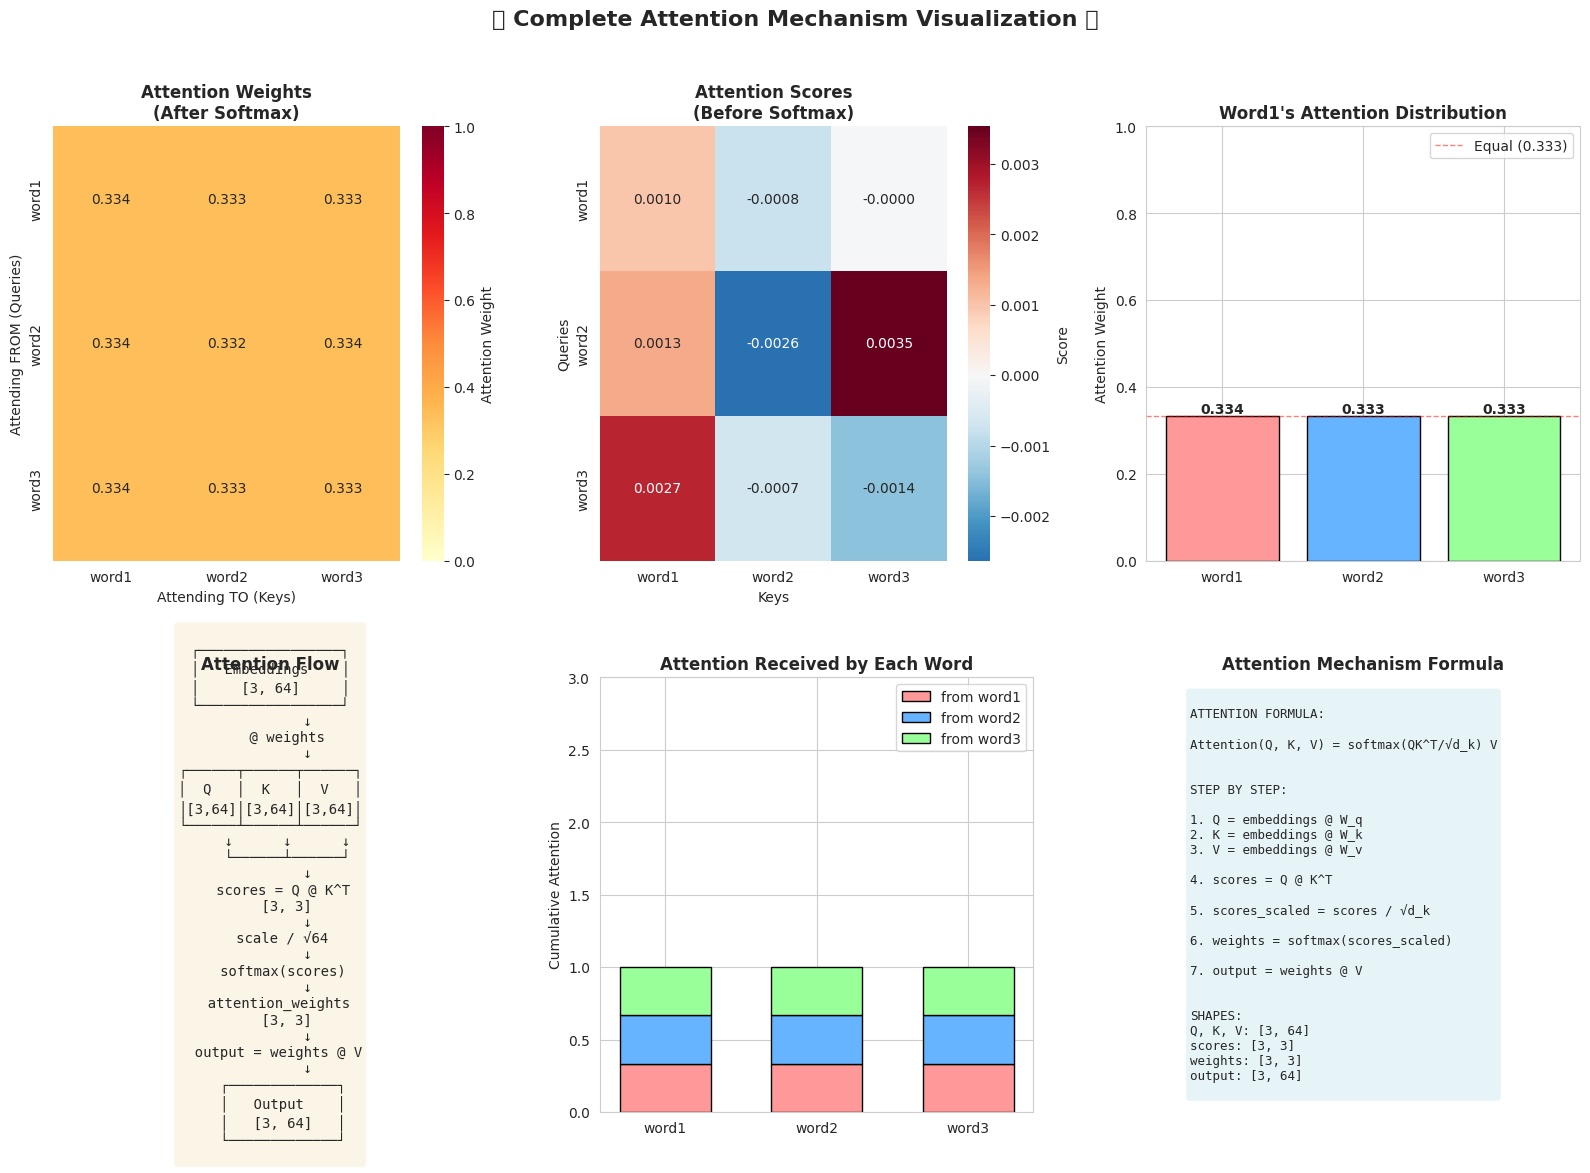


✅ Visualization complete!

💡 What you're seeing:
  1. Top-left: Final attention weights (probabilities)
  2. Top-middle: Raw scores before softmax
  3. Top-right: How word1 distributes its attention
  4. Bottom-left: The complete attention flow
  5. Bottom-middle: How much attention each word receives
  6. Bottom-right: The mathematical formula


In [26]:
"""
Visualize everything we built!
"""

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style
sns.set_style("whitegrid")

# Create a large figure with multiple subplots
fig = plt.figure(figsize=(16, 12))

# ============================================
# 1. ATTENTION WEIGHTS HEATMAP
# ============================================
ax1 = plt.subplot(2, 3, 1)
sns.heatmap(attention_weights.detach().numpy(), 
            annot=True, 
            fmt='.3f',
            cmap='YlOrRd',
            xticklabels=['word1', 'word2', 'word3'],
            yticklabels=['word1', 'word2', 'word3'],
            cbar_kws={'label': 'Attention Weight'},
            vmin=0, vmax=1,
            ax=ax1)
ax1.set_title('Attention Weights\n(After Softmax)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Attending TO (Keys)')
ax1.set_ylabel('Attending FROM (Queries)')

# ============================================
# 2. ATTENTION SCORES (Before Softmax)
# ============================================
ax2 = plt.subplot(2, 3, 2)
sns.heatmap(attention_scores_scaled.detach().numpy(), 
            annot=True, 
            fmt='.4f',
            cmap='RdBu_r',
            center=0,
            xticklabels=['word1', 'word2', 'word3'],
            yticklabels=['word1', 'word2', 'word3'],
            cbar_kws={'label': 'Score'},
            ax=ax2)
ax2.set_title('Attention Scores\n(Before Softmax)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Keys')
ax2.set_ylabel('Queries')

# ============================================
# 3. BAR CHART: Word1's Attention Distribution
# ============================================
ax3 = plt.subplot(2, 3, 3)
words = ['word1', 'word2', 'word3']
weights_word1 = attention_weights[0].detach().numpy()
bars = ax3.bar(words, weights_word1, color=['#ff9999', '#66b3ff', '#99ff99'], edgecolor='black')
ax3.set_ylim([0, 1])
ax3.set_ylabel('Attention Weight')
ax3.set_title("Word1's Attention Distribution", fontsize=12, fontweight='bold')
ax3.axhline(y=1/3, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Equal (0.333)')
ax3.legend()
for i, (bar, weight) in enumerate(zip(bars, weights_word1)):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{weight:.3f}',
             ha='center', va='bottom', fontweight='bold')

# ============================================
# 4. ATTENTION FLOW DIAGRAM
# ============================================
ax4 = plt.subplot(2, 3, 4)
ax4.axis('off')

# Draw the flow
flow_text = """
┌─────────────────┐
│   Embeddings    │
│     [3, 64]     │
└─────────────────┘
         ↓
    @ weights
         ↓
┌──────┬──────┬──────┐
│  Q   │  K   │  V   │
│[3,64]│[3,64]│[3,64]│
└──────┴──────┴──────┘
    ↓      ↓      ↓
    └──────┴──────┘
         ↓
   scores = Q @ K^T
    [3, 3]
         ↓
   scale / √64
         ↓
   softmax(scores)
         ↓
  attention_weights
    [3, 3]
         ↓
  output = weights @ V
         ↓
   ┌─────────────┐
   │   Output    │
   │   [3, 64]   │
   └─────────────┘
"""

ax4.text(0.5, 0.5, flow_text, 
         transform=ax4.transAxes,
         fontsize=10,
         verticalalignment='center',
         horizontalalignment='center',
         family='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
ax4.set_title('Attention Flow', fontsize=12, fontweight='bold')

# ============================================
# 5. EACH WORD'S ATTENTION (Stacked Bar)
# ============================================
ax5 = plt.subplot(2, 3, 5)
words = ['word1', 'word2', 'word3']
width = 0.6

# Create stacked bars
bottom = np.zeros(3)
colors = ['#ff9999', '#66b3ff', '#99ff99']
for i in range(3):
    values = attention_weights[:, i].detach().numpy()
    ax5.bar(words, values, width, bottom=bottom, 
            label=f'from {words[i]}', color=colors[i], edgecolor='black')
    bottom += values

ax5.set_ylabel('Cumulative Attention')
ax5.set_title('Attention Received by Each Word', fontsize=12, fontweight='bold')
ax5.legend()
ax5.set_ylim([0, 3])

# ============================================
# 6. FORMULA DISPLAY
# ============================================
ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')

formula_text = """
ATTENTION FORMULA:

Attention(Q, K, V) = softmax(QK^T/√d_k) V


STEP BY STEP:

1. Q = embeddings @ W_q
2. K = embeddings @ W_k  
3. V = embeddings @ W_v

4. scores = Q @ K^T

5. scores_scaled = scores / √d_k

6. weights = softmax(scores_scaled)

7. output = weights @ V


SHAPES:
Q, K, V: [3, 64]
scores: [3, 3]
weights: [3, 3]
output: [3, 64]
"""

ax6.text(0.1, 0.5, formula_text,
         transform=ax6.transAxes,
         fontsize=9,
         verticalalignment='center',
         family='monospace',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))
ax6.set_title('Attention Mechanism Formula', fontsize=12, fontweight='bold')

# ============================================
# MAIN TITLE
# ============================================
fig.suptitle('🎯 Complete Attention Mechanism Visualization 🎯', 
             fontsize=16, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print("\n✅ Visualization complete!")
print("\n💡 What you're seeing:")
print("  1. Top-left: Final attention weights (probabilities)")
print("  2. Top-middle: Raw scores before softmax")
print("  3. Top-right: How word1 distributes its attention")
print("  4. Bottom-left: The complete attention flow")
print("  5. Bottom-middle: How much attention each word receives")
print("  6. Bottom-right: The mathematical formula")